In [1]:
# Header. This is hidden from sphinx with the json metadata:
#   {"nbsphinx":"hidden"}

# ipython configuration (reloads source code automatically and plots inline)
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, sys
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rc('image', cmap='inferno')

### Pixel Calibration

An ideal SLM would be able to accurately shift its pixels to a desired phase $\phi$.
Real SLMs require calibration to be able to phase shift accurately.
This process is sometimes called "phase calibration", "gamma calibration", or "LUT calibration"
(after the resulting "look-up table" between bitlevel and phase).
In this tutorial, we're using a Texas Instruments phase light modulator (PLM) with only 4-bit depth
(16 states). These states are fairly nonlinear as well, which makes LUT calibration especially important.

In this example, we will:

- Measure the phase of each level and compare it with the vendor's LUT,
- See what the difference means for a hologram, and
- Measure how long the SLM takes to respond to a new pattern.

#### Loading Hardware

We load the same hardware as in the
[experimental holography](https://slmsuite.holodyne.com/en/latest/_examples/experimental_holography.html) tutorial: a PLM
(`'p67'`; 1358 $\times$ 800 pixels, 10.8 µm pitch) illuminated at 488 nm, and a FLIR camera.
As in the [simulated hardware](https://slmsuite.holodyne.com/en/latest/_examples/simulated_hardware.html) tutorial, we Fourier
calibrate on the full sensor, then crop a 1024 $\times$ 1024 window around the zeroth order.
We don't load a LUT or wavefront calibration: both calibrations in this notebook display
their patterns without wavefront correction.

In [2]:
# ======================================== README ========================================
# ---------------- (This cell is hidden from readthedocs rendering) ---------------------
# If you're running this notebook without our hardware, run this cell instead of the
# next two. It loads a simulated clone of our setup (see the simulated hardware tutorial)
# to stand in for the hardware, and gives it the vendor's LUT.
from slmsuite.hardware.cameraslms import FourierSLM
from slmsuite.hardware.slms.texasinstruments import PLM

fs = FourierSLM.load("simulated_setup.h5")
cam, slm = fs.cam, fs.slm
slm.set_gamma(np.array(PLM.load_model_config("p67")["displacement_ratios"]) * 15 / 16);

[INF] 22:29:50 p67_sim Initialized SimulatedSLM.
[INF] 22:29:50 p67_sim Using GPU (cupy) backend.
[INF] 22:29:50 flir_sim Initialized SimulatedCamera.
[INF] 22:29:50 Hologram Initialized Hologram.
[INF] 22:29:50 flir_sim-p67_sim Initialized FourierSLM.
[WRN] 22:29:50 flir_sim Camera extends beyond the accessible SLM k-space; some pixels may not be targetable.
[INF] 22:29:50 Hologram #2 Initialized Hologram.


In [3]:
from slmsuite.hardware.slms.texasinstruments import PLM
from slmsuite.hardware.cameras.flir import FLIR
from slmsuite.hardware.cameraslms import FourierSLM

slm = PLM('p67', display_number=2, configure_usb=True, usb_device_number=1,
          wav_um=0.488, settle_time_s=0.05, name='PLM')
cam = FLIR(serial="22562470", pitch_um=2.74, bitdepth=12, name="FLIR Cam")
cam.set_woi(None)                   # Full sensor.
fs = FourierSLM(cam, slm)

[INF] 22:29:51 PLM Initialized PLM on display 2.
[INF] 22:29:51 PLM Using GPU (cupy) backend.
[INF] 22:29:56 FLIR Cam Initialized FLIR.
[INF] 22:29:56 FLIR Cam-PLM Initialized FourierSLM.


[INF] 22:29:56 Fourier Grid Initialized SpotHologram.


Fourier Grid: 100%|██████████| 10/10 [00:00<00:00, 469.20it/s]


[INF] 22:29:58 FLIR Cam Autoexpose: 1.89e-03 s - 2001/4095


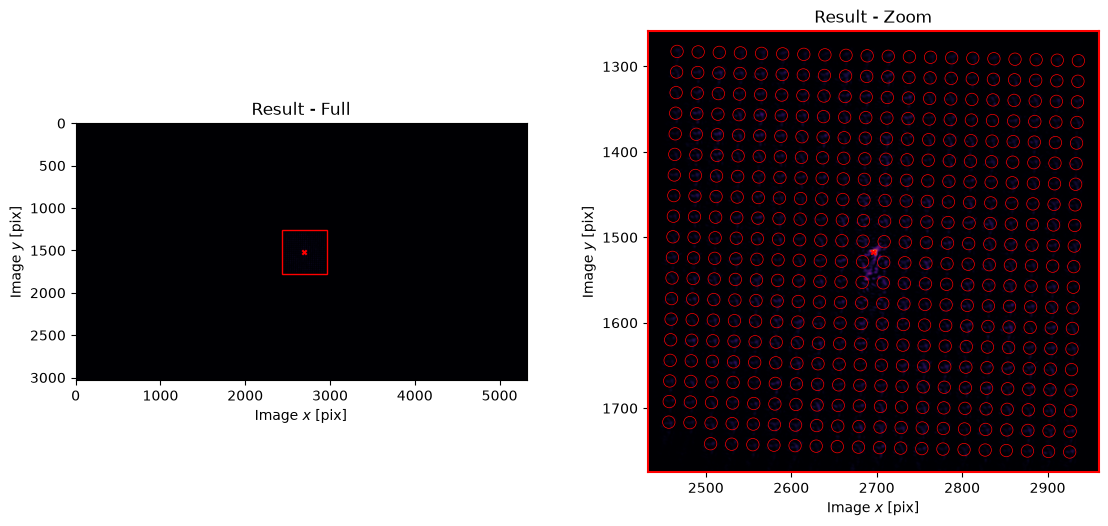

In [4]:
fs.fourier_calibrate(array_shape=20, array_pitch=20, autoexpose=True, plot=True);

In [5]:
x, y = fs.zeroth_order_ij.ravel()
cam.set_woi((int(x) - 512, 1024, int(y) - 512, 1024));

[WRN] 22:30:01 FLIR Cam Attempted to set WOI to (2184, 1024, 1004, 1024), but realized (2184, 1024, 1000, 1024).


#### Vendor Look-Up Table (LUT)

Texas Instruments provides a suggested LUT for each PLM family (termed "displacement ratios").
This is loaded into the PLM object on initialization: the phase of each level is stored as
`slm.gamma`, and the table that picks a level for each desired phase as `slm.lut`.
We keep a copy of the vendor's version to compare against later.

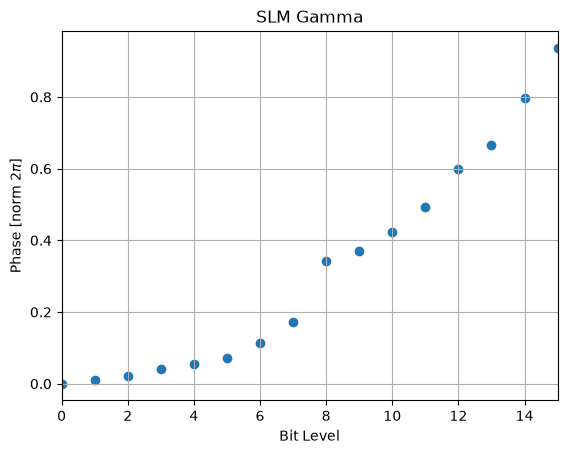

In [6]:
from slmsuite.misc.xp import as_numpy

vendor = as_numpy(slm.gamma).copy()
slm.plot_gamma();

#### Running the Calibration

[.pixel_calibrate()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameraslms.FourierSLM.html#slmsuite.hardware.cameraslms.FourierSLM.pixel_calibrate)
projects a series of binary gratings with levels set to $a$ and $b$.
The camera measures the power in each diffraction order, and the relative strengths
determine the phase difference between the two levels. In most cases, the default
arguments work, but we summarize the main options here:

- `levels` programs which levels to test: an array can be passed directly, or an integer specifying the number of levels to sample (rounded up to the next power of two). We're running this notebook on a 4-bit SLM, so we test all 16 levels.
- `periods` specifies the grating period(s) to measure at. By default, a sensible set is chosen which fits within the camera's field of view.
- `orders` specifies which diffraction orders to measure. For LUT calibration, the $\pm 1$ orders are most important.

As with wavefront calibration, we can check a `test_index` before starting the full sweep.
`test_index=True` steps through one row of the sweep and sets an exposure that saturates
none of it. Then let's look at the index where $a = 0$ and $b = 10$.

[INF] 22:30:02 FLIR Cam Autoexpose: 5.50e-05 s - 2006/4095
[INF] 22:30:02 FLIR Cam Autoexpose: 5.50e-05 s - 2029/4095
[INF] 22:30:03 FLIR Cam Autoexpose: 5.50e-05 s - 2101/4095
[INF] 22:30:03 FLIR Cam Autoexpose: 5.50e-05 s - 2134/4095
[INF] 22:30:03 FLIR Cam Autoexpose: 5.50e-05 s - 2047/4095
[INF] 22:30:03 FLIR Cam Autoexpose: 5.50e-05 s - 2119/4095
[INF] 22:30:03 FLIR Cam Autoexpose: 5.50e-05 s - 1935/4095
[INF] 22:30:04 FLIR Cam Autoexpose: 8.10e-05 s - 2178/4095
[INF] 22:30:04 FLIR Cam Autoexpose: 1.60e-04 s - 1931/4095
[INF] 22:30:04 FLIR Cam Autoexpose: 1.60e-04 s - 1916/4095
[INF] 22:30:04 FLIR Cam Autoexpose: 1.33e-04 s - 1918/4095
[INF] 22:30:05 FLIR Cam Autoexpose: 1.33e-04 s - 2106/4095
[INF] 22:30:05 FLIR Cam Autoexpose: 1.33e-04 s - 1879/4095
[INF] 22:30:05 FLIR Cam Autoexpose: 1.86e-04 s - 2130/4095
[INF] 22:30:05 FLIR Cam Autoexpose: 5.50e-05 s - 1747/4095
[INF] 22:30:06 FLIR Cam Autoexpose: 5.50e-05 s - 2061/4095


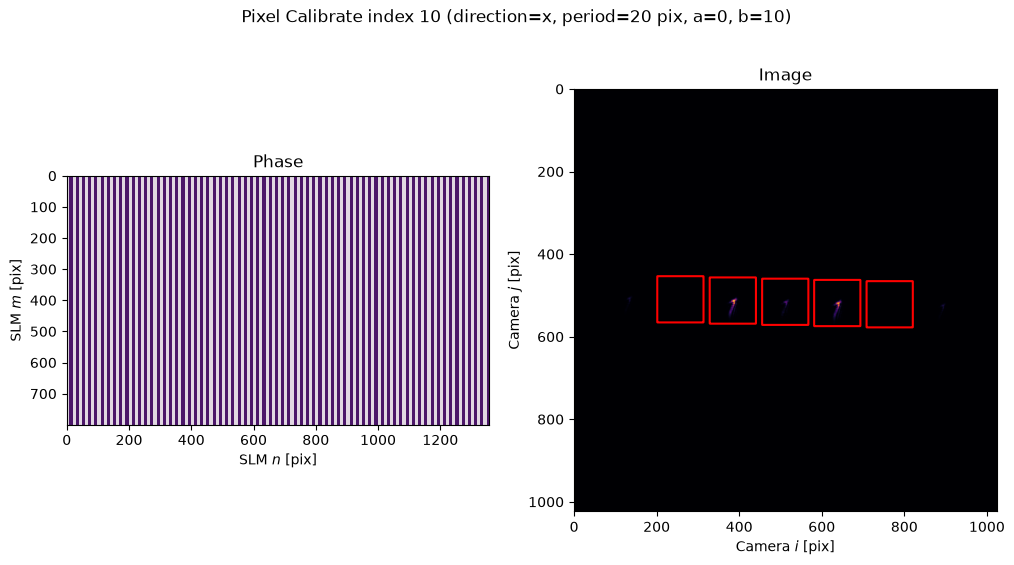

In [7]:
fs.pixel_calibrate(levels=16, test_index=True, autoexpose=True);
fs.pixel_calibrate(levels=16, test_index=10, plot=True);

Now we run the full sweep. The raw data is the power in each order versus the levels $a$ and $b$.
Notice that power moves between the 0th order and the $\pm 1$ orders as the phase
difference between the levels changes.

100%|██████████| 1024/1024 [01:26<00:00, 11.78it/s]


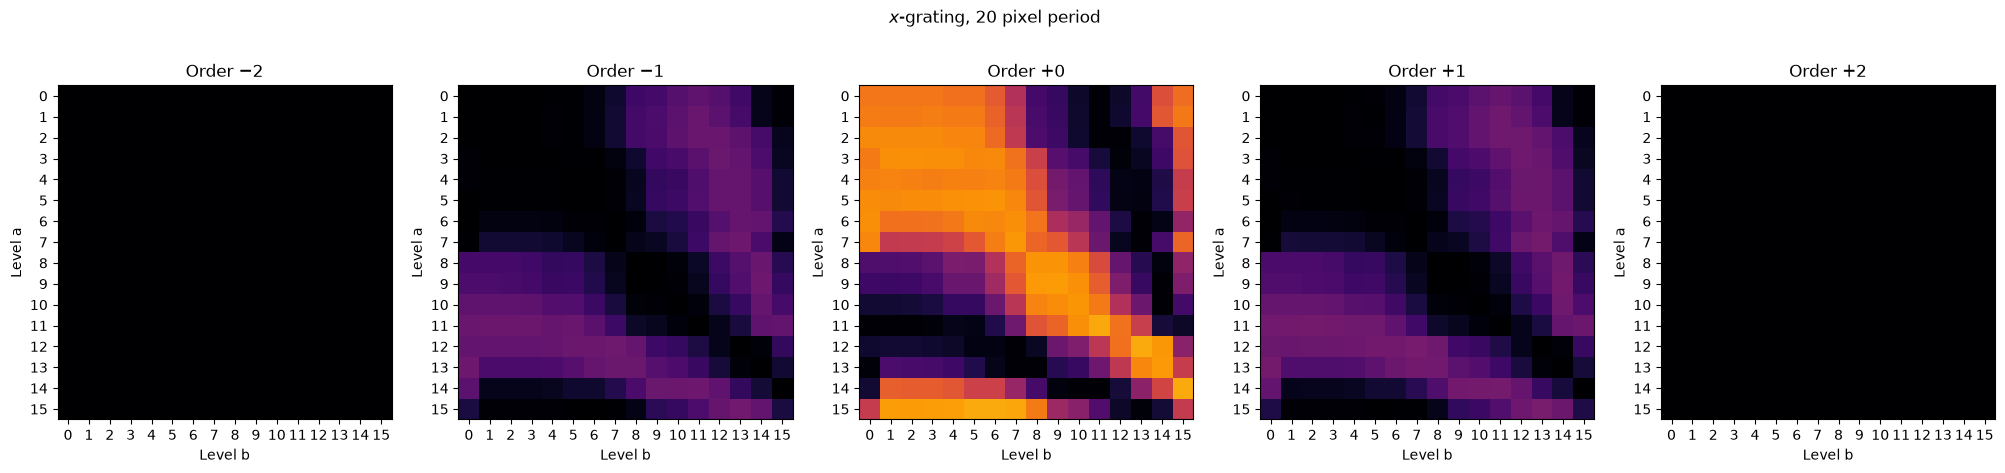

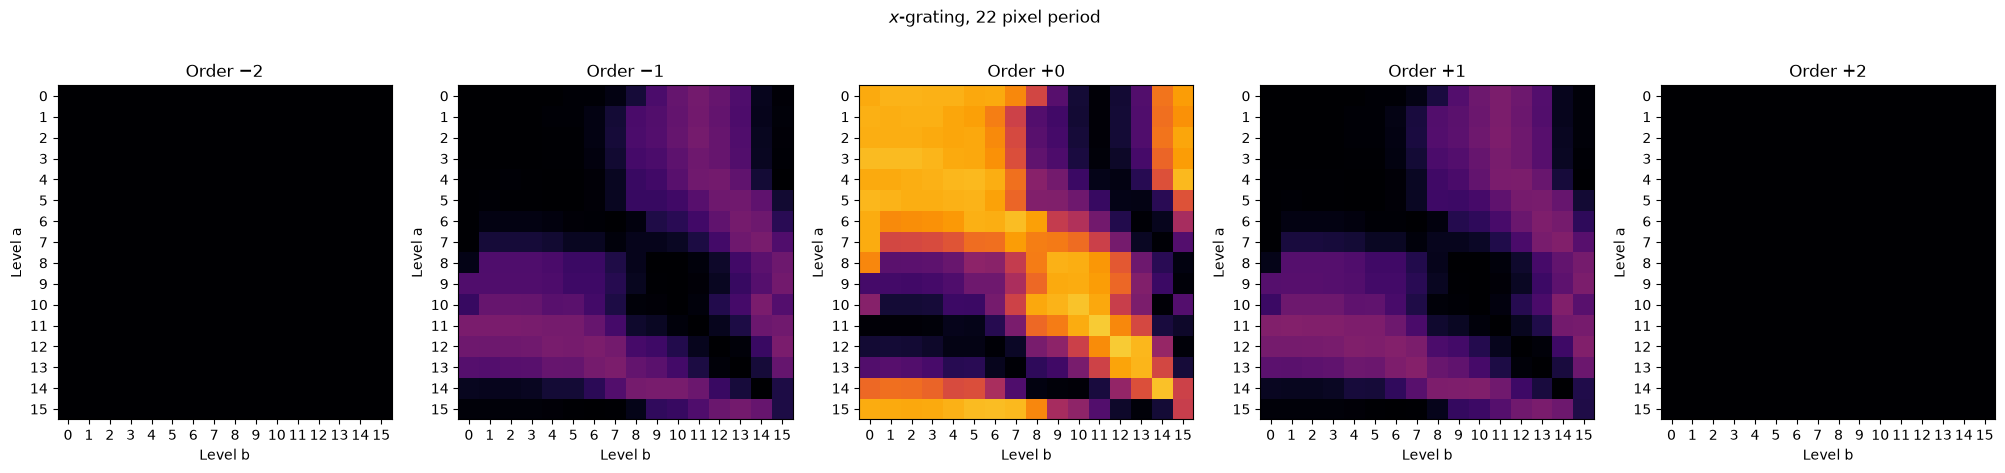

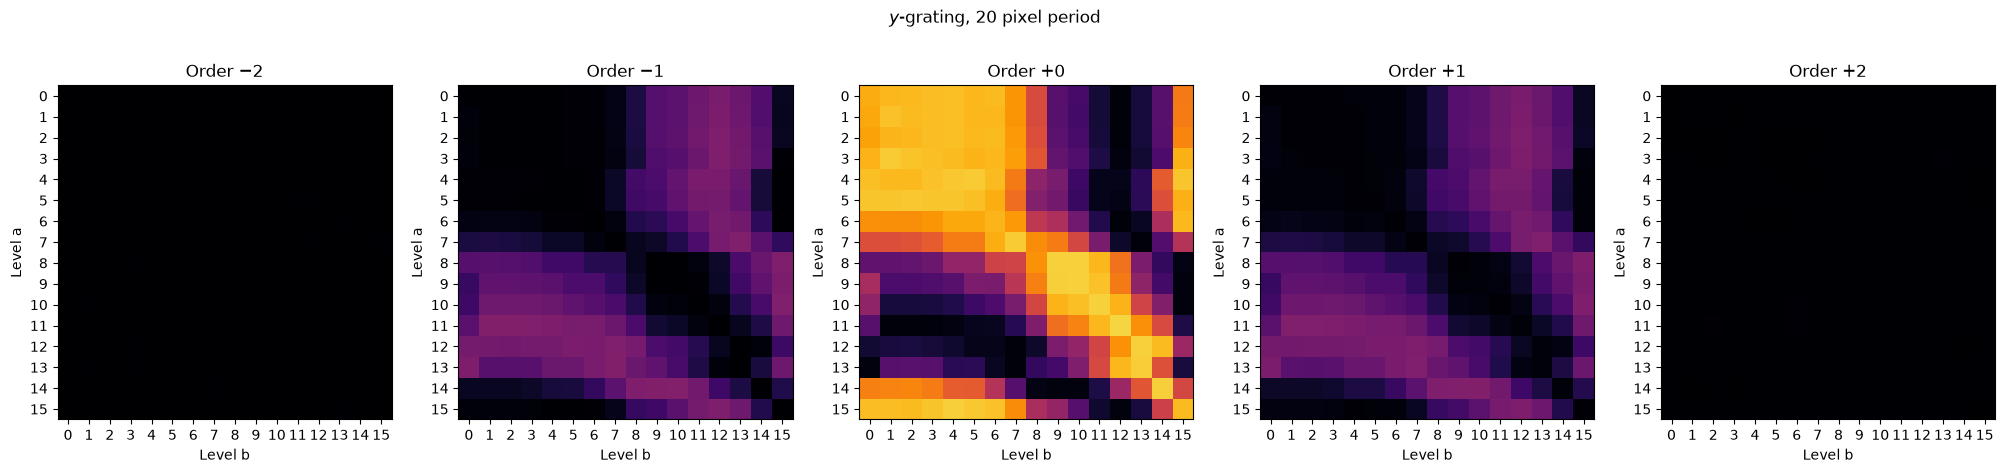

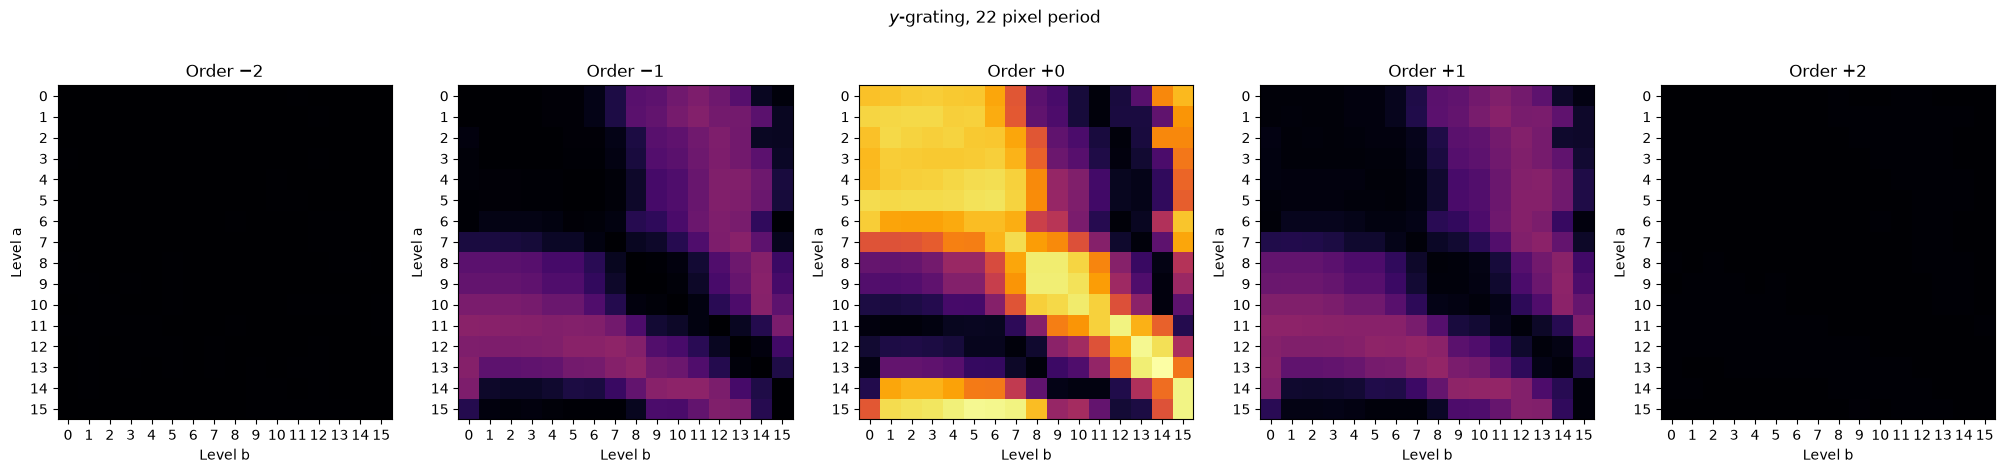

In [8]:
fs.pixel_calibrate(levels=16)
fs.pixel_calibration_plot()

A fit converts this 2D data into the phase of each level.

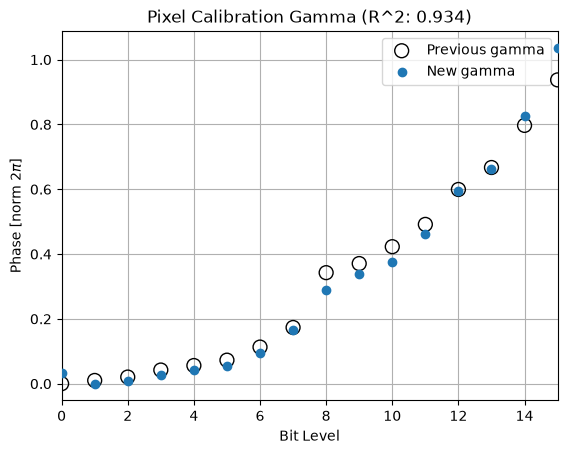

In [9]:
gamma = fs.pixel_calibration_process(plot=1)

Let's check that this is repeatable by running the calibration two more times.

In [10]:
gammas = [gamma]
for _ in range(2):
    fs.pixel_calibrate(levels=16)
    gammas.append(fs.pixel_calibration_process(apply=False))

gamma = np.mean(gammas, axis=0)
slm.set_gamma(gamma);

print("Run-to-run spread: {:.3f} x 2pi (worst level)".format(np.std(gammas, axis=0).max()))

100%|██████████| 1024/1024 [01:26<00:00, 11.78it/s]

Run-to-run spread: 0.010 x 2pi (worst level)


#### Vendor versus Measured

The three runs agree closely (the printed spread is a small fraction of the $1/16$ step between levels), so we use their average.
The measured phase deviates from the vendor's most at levels 8–9 and 14–15.
For a PLM, some deviation is expected because device performance depends on a
user-supplied voltage setpoint.

The left plot compares the phase of each level. The right plot shows what this means in
practice: for each phase we request, the LUT picks a level, and the measured `gamma` tells
us the phase that level actually produces. With only 16 levels, even a perfect LUT is off by
up to half a step (the sawtooth), but the vendor LUT adds a systematic error on top.

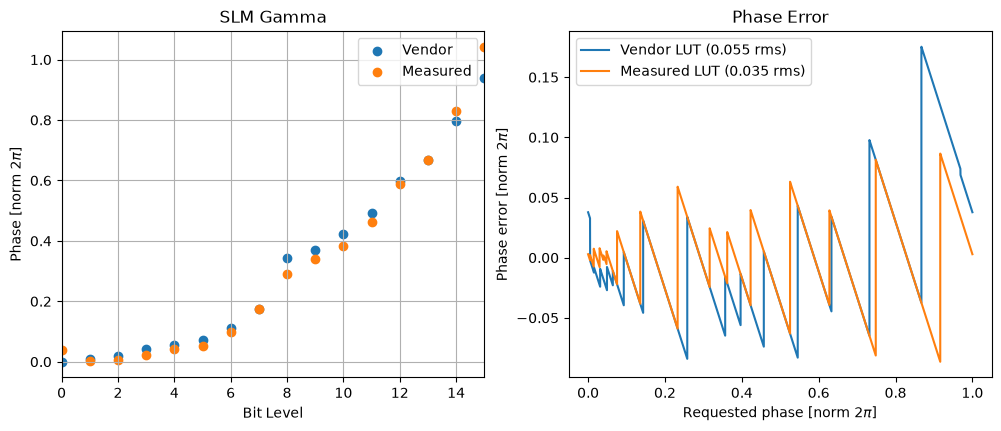

In [11]:
requested = np.arange(len(slm.lut)) / len(slm.lut)     # Phase grid of the LUT [2pi].

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
slm.plot_gamma(vendor, ax=axs[0], label="Vendor")
slm.plot_gamma(gamma, ax=axs[0], label="Measured")
axs[0].legend()

for g, label in ((vendor, "Vendor LUT"), (gamma, "Measured LUT")):
    slm.set_gamma(g)
    realized = gamma[as_numpy(slm.lut)]                 # Phase of the level the LUT picks.
    error = np.mod(realized - requested + .5, 1) - .5
    axs[1].plot(requested, error, label="{} ({:.3f} rms)".format(label, np.sqrt(np.mean(error ** 2))))

axs[1].set_xlabel(r"Requested phase [norm $2\pi$]")
axs[1].set_ylabel(r"Phase error [norm $2\pi$]")
axs[1].set_title("Phase Error")
axs[1].legend()
plt.show()

To see this on the camera, we display a blazed grating with a 16 pixel period using each
LUT, and measure the power in orders $-2$ to $+2$. Any phase error moves power out of the
$+1$ order and into the others (log scale).

[INF] 22:34:29 FLIR Cam Autoexpose: 2.90e-05 s - 1718/4095


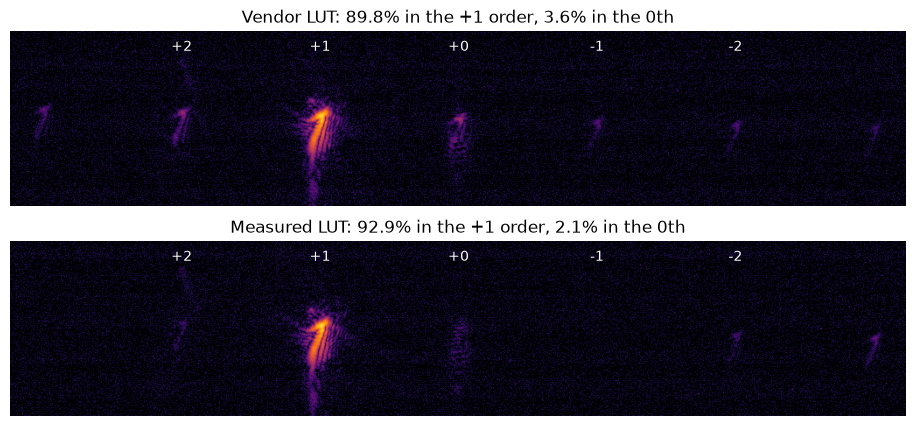

In [12]:
from slmsuite.holography import analysis, toolbox

vector = toolbox.convert_vector((1/16, 0), from_units="freq", to_units="norm", hardware=fs)
blaze = toolbox.phase.blaze(slm, vector)
orders = np.arange(-2, 3)
order_ij = fs.kxyslm_to_ijcam(np.outer(vector, orders))
y = int(order_ij[1].mean())

slm.set_phase(blaze, phase_correct=False, settle=True)
cam.autoexpose(set_fraction=.5)

fig, axs = plt.subplots(2, 1, figsize=(12, 5))
for ax, g, label in zip(axs, (vendor, gamma), ("Vendor LUT", "Measured LUT")):
    slm.set_gamma(g)
    slm.set_phase(blaze, phase_correct=False, settle=True)
    img = cam.get_image()
    img = np.clip(img - np.median(img), 0, None)
    power = analysis.take(img, order_ij, size=100, integrate=True)
    power /= power.sum()

    ax.imshow(np.log10(img[y-100:y+100] + 1), vmin=0, vmax=np.log10(cam.bitresolution))
    ax.set_title("{}: {:.1%} in the +1 order, {:.1%} in the 0th".format(
        label, power[orders == 1][0], power[orders == 0][0]))
    for o, (i, _) in zip(orders, order_ij.T):
        ax.annotate("{:+d}".format(o), (i, 10), color="w", ha="center", va="top")
    ax.axis("off")
plt.show()

slm.set_gamma(gamma);

With the measured LUT, the $+1$ order gains power and the 0th order loses it (the titles
give the fractions). The measured LUT cannot remove all of the phase error:
levels 0–5 sit within about $0.05 \times 2\pi$ of each other, which leaves a gap that
no choice of levels can fill.

### Settle Calibration

We now move on to a topic separate from LUT calibration: measuring the response time of the SLM.
Every `set_phase(..., settle=True)` above waited `slm.settle_time_s` (50 ms, set when we
loaded the PLM) before reading the camera. Reading too early measures the previous pattern,
or one in transit.

[.settle_calibrate()](https://slmsuite.holodyne.com/en/latest/_autosummary/slmsuite.hardware.cameraslms.FourierSLM.html#slmsuite.hardware.cameraslms.FourierSLM.settle_calibrate)
measures how long is long enough. For each delay $t$ in `times` (in random order), it displays
a flat pattern for `settle_time_s`, switches to a blaze, waits $t$, and measures the power in
the blazed spot. It then fits a delayed exponential: the delay is the *communication time*
(before the SLM starts to change), and the suggested settle time adds four time constants
of the exponential. With `plot=2`, it first shows both patterns and the integration region.

[INF] 22:34:30 FLIR Cam Autoexpose: 2.90e-05 s - 1675/4095


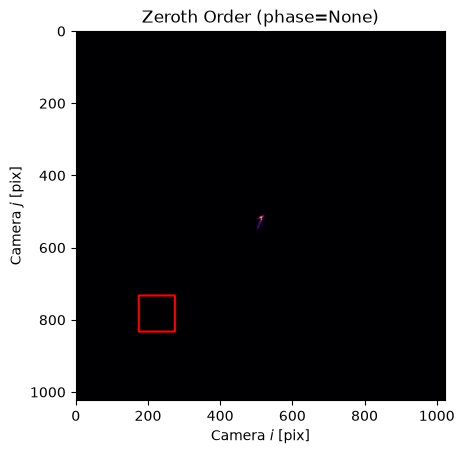

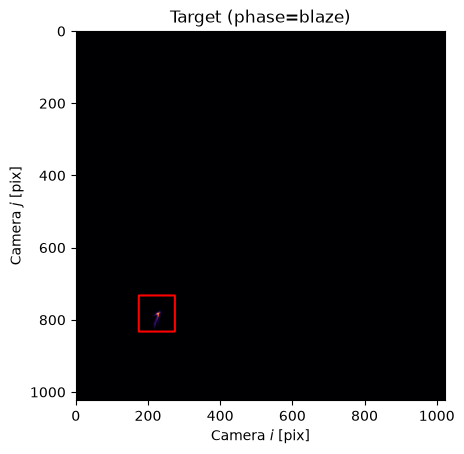

100%|██████████| 201/201 [01:07<00:00,  2.97it/s]


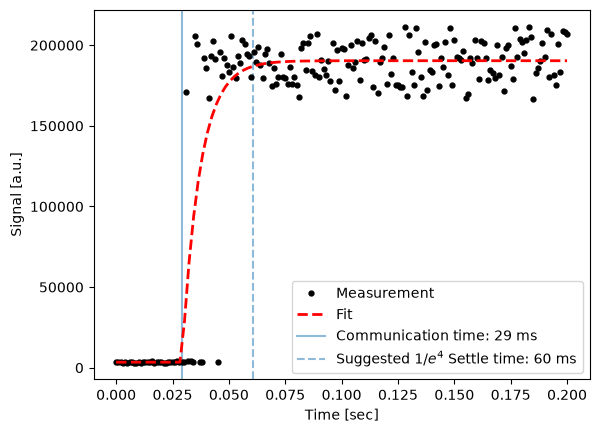

In [13]:
fs.settle_calibrate(
    vector=(.005, .005),
    times=np.linspace(0, .2, 201),
    plot=2,
    size=100
);

We're using a PLM (response time in the 10s of microseconds) to build this notebook, so the
plot here is confounded. A liquid-crystal SLM would have a smooth response following the
exponential fit. However, the PLM response is instantaneous compared with our camera
exposure, so we only ever catch the system in either the fully unblazed or fully blazed
configuration. What varies from shot to shot is *when* the transition happens, which is set
by the display interface driving the PLM. The display has its own clock (around 60 Hz, or
16 ms) and pushes frames according to that clock, which may or may not align with the time
at which we requested the frame. The exponential fit still serves its purpose of suggesting
a settle time that will statistically yield accurate frames. Compare it with the 50 ms we
used above: if the suggestion is longer, a few shots may still catch the previous pattern,
and we can raise `slm.settle_time_s` to match.

In [14]:
cam.close()
slm.close()